First of all, set the 'CODE_DIR' to where the model code are saved. This will change current working directory and print for checking. Afterwards, we import all required modules.

In [1]:
import os

# Save the current PATH
original_path = os.environ['PATH']

# Set CUDA 12.5 environment variables, appending the original PATH explicitly
os.environ['CUDA_HOME'] = '/usr/local/cuda-12.5'
os.environ['PATH'] = f"/usr/local/cuda-12.5/bin:{original_path}"
os.environ['LD_LIBRARY_PATH'] = f"/usr/local/cuda-12.5/lib64:{os.environ.get('LD_LIBRARY_PATH', '')}"

#!rm -rf /home/ids/yuhe/.cache/torch_extensions

CODE_DIR = '/home/ids/yuhe/Projects/CA_with_GAN/3_code/styleGAN/pSp_encoder_constructive'

import os
os.chdir(f'{CODE_DIR}')

notebook_path = os.getcwd()
print('Current working directory is:', '\n', notebook_path) 

Current working directory is: 
 /home/ids/yuhe/Projects/CA_with_GAN/3_code/styleGAN/pSp_encoder_constructive


In [2]:

from argparse import Namespace
import time
import sys
import pprint
import numpy as np
from PIL import Image
import torch
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
from IPython.display import display

sys.path.append(".")
sys.path.append("..")

# from datasets import augmentations
from utils.common import tensor2im, log_input_image
# from models.psp import pSp

from notebooks.def_funcs import load_sparsity_model, load_ema_model, evaluate_model, transform_images_to_batch, load_folder_images, \
    show_latent_map, visulize_singleImg_paired2, visulize_singleImg_paired3, visulize_singleImg_paired4, visulize_singleImg_paired5, evaluate_learn_scaled_st, evaluate_scaled_st
# %load_ext autoreload
# %autoreload 2

## Parameters setting

Fell free to change the golobal parameters for all experiments

In [3]:
import torch
import h5py
from torch.utils.data import Dataset

class LatentClassifierDataset(Dataset):
    def __init__(self, hdf5_paths, labels):
        """
        Args:
            hdf5_paths (list): List of HDF5 file paths (bg and glass).
            labels (list): Corresponding labels (0 for bg, 1 for glass).
        """
        self.hdf5_paths = hdf5_paths
        self.labels = labels
        self.data = []

        # Load filenames and labels from both HDF5 files
        for hdf5_path, label in zip(hdf5_paths, labels):
            with h5py.File(hdf5_path, "r") as f:
                filenames = list(f.keys())  # Get all image keys
                for filename in filenames:
                    self.data.append((hdf5_path, filename, label))  # Store filename, path, label

    def __len__(self):
        return len(self.data)

    def __getitem__(self, index):
        hdf5_path, filename, label = self.data[index]

        with h5py.File(hdf5_path, "r") as f:
            latent_c = torch.tensor(f[filename]["latent_c"][:], dtype=torch.float32).flatten()
            latent_s = torch.tensor(f[filename]["latent_s"][:], dtype=torch.float32).flatten()
            w_pSp = torch.tensor(f[filename]["w_pSp"][:], dtype=torch.float32).flatten()

        return filename, latent_c, latent_s, w_pSp, torch.tensor(label, dtype=torch.float32)  # Include filename


### Set parameters

### Load pretrained pSp model

In [4]:
import pandas as pd
import torch

def evaluate_model(model, test_dataloader, device, save_path=None):
    """
    Evaluate the trained model on test latents and save results to CSV.

    Args:
        model (torch.nn.Module): The trained model.
        test_dataloader (DataLoader): DataLoader for test data.
        device (torch.device): Device (CPU/GPU).
        save_path (str, optional): Path to save results as CSV.

    Returns:
        None (Prints results or saves to a file)
    """
    model.eval()  # Set model to evaluation mode
    results = []

    with torch.no_grad():  # Disable gradient computation
        correct = 0
        total = 0

        for filenames, latent_c, _, _, labels in test_dataloader:
            latent_c, labels = latent_c.to(device), labels.float().to(device)

            # Forward pass
            logits = model(latent_c).squeeze()  # Raw outputs (logits)
            probs = torch.sigmoid(logits)  # Convert to probabilities
            predictions = (probs > 0.5).float()  # Convert to binary (0 or 1)

            # Store batch results
            for i in range(latent_c.shape[0]):  # Iterate over batch
                results.append({
                    "Filename": filenames[i],  # Save filename in first column
                    "True Label": int(labels[i].item()),
                    "Predicted Label": int(predictions[i].item()),
                    "Probability": round(probs[i].item(), 4)
                })

            # Compute accuracy
            correct += (predictions == labels).sum().item()
            total += labels.size(0)

    accuracy = correct / total
    print(f"\n✅ Evaluation Complete! Accuracy: {accuracy:.4f}")

    # Save results to file if save_path is provided
    if save_path:
        df = pd.DataFrame(results)
        df.to_csv(save_path, index=False)
        print(f"📁 Results saved to: {save_path}")

import torch
import os

def load_model(checkpoint_path, model, device):
    """
    Load a trained model from a checkpoint.

    Args:
        checkpoint_path (str): Path to the checkpoint file.
        model (torch.nn.Module): The model architecture.
        device (torch.device): Device to load the model on (CPU or GPU).

    Returns:
        torch.nn.Module: Loaded model.
    """
    model.load_state_dict(torch.load(checkpoint_path, map_location=device))
    model.to(device)
    model.eval()  # Set to evaluation mode
    print(f"✅ Loaded model from {checkpoint_path}")
    return model


### Perform encode and decode for inversion

In [18]:
# Load test dataset
test_dataloader = torch.utils.data.DataLoader(
    LatentClassifierDataset(
        hdf5_paths=["datasets/inferences/baseline/train/latents_bg_130k.h5",
                    "datasets/inferences/baseline/train/latents_glass_130k.h5"], 
        labels=[0, 1]
    ), 
    batch_size=4, shuffle=False, num_workers=4
)


In [19]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
from training_cls.cls_models import CustomLatentClassifier
# Load trained model (Change checkpoint filename as needed)
checkpoint_path = "training_cls/results/sample_cls/1layer_lr0.0001_bs4/checkpoints/model_epoch_40.pth"
model = CustomLatentClassifier(input_dim=18*512, num_layers=1)  # Adjust num_layers if needed
model = load_model(checkpoint_path, model, device)

# Run evaluation and save results
evaluate_model(model, test_dataloader, device, save_path="evaluation_results.csv")


✅ Loaded model from training_cls/results/sample_cls/1layer_lr0.0001_bs4/checkpoints/model_epoch_40.pth

✅ Evaluation Complete! Accuracy: 0.9730
📁 Results saved to: evaluation_results.csv


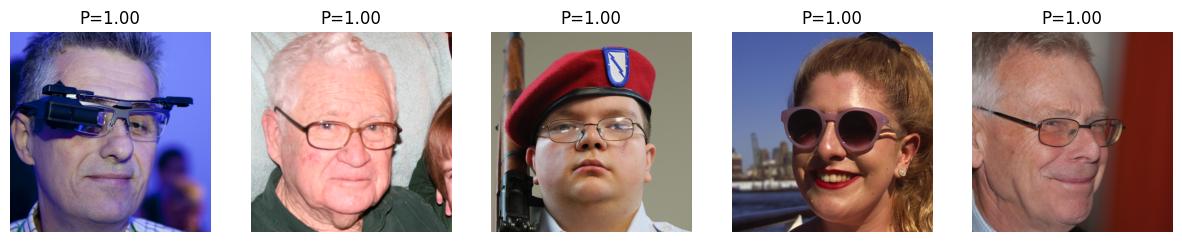

In [21]:
import pandas as pd
import random
import os
import matplotlib.pyplot as plt
from PIL import Image

# ✅ Step 1: Load CSV file
csv_path = "evaluation_results.csv"  # Update with your CSV path
df = pd.read_csv(csv_path)

# ✅ Step 2: Randomly select 5 images along with probabilities
random_samples = df.sample(n=5)  # Randomly select 5 rows

# ✅ Step 3: Define image directory
image_dir = "/home/ids/yuhe/Projects/CA_with_GAN/2_data/styleGAN/ffhq_1024"
%matplotlib inline
# ✅ Step 4: Load and display images
fig, axes = plt.subplots(1, 5, figsize=(15, 5))

for i, row in enumerate(random_samples.itertuples()):
    filename = row.Filename
    probability = row.Probability  # Get probability from CSV

    image_path = os.path.join(image_dir, filename)

    if os.path.exists(image_path):  # Check if file exists
        img = Image.open(image_path)
        axes[i].imshow(img)
        axes[i].axis("off")
        axes[i].set_title(f"P={probability:.2f}")  # Show probability as title
    else:
        print(f"⚠️ Image not found: {image_path}")

plt.show()
